# 04. Interpretability

What the white box says, what the black box uses, why this pair, whether each column earns its place,
whether the methods agree, and what the engine is worth. Each section ends with **what it says** and
**what to conclude**.

**One convention, shared with 05, 06 and 07.** Ŷ = 1 means the pair is in the **top decile**. At a
16.5% base rate with a score that is a product of two probabilities, no pair reaches 0.5, so a
threshold classifier predicts nothing. SHAP is computed per decision stage for the same reason.

In [1]:
%matplotlib inline

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, r2_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from xgboost import XGBClassifier

if not Path("data").is_dir():
    os.chdir("..")   # works whether Jupyter started at the repo root or inside notebooks/

Path("reports/figures").mkdir(parents=True, exist_ok=True)
Path("reports/tables").mkdir(parents=True, exist_ok=True)

SEED = 42
table = pd.read_csv("data/processed/model_table.csv")
oof = pd.read_csv("data/processed/oof_predictions.csv")
print(table.shape, oof.shape)

/private/tmp/claude-501/-Users-justinmartin-Documents-HEC-M2-Cours-Classes-02---Interpretability--Stability---Algorithmic-fairness-02---Project/06a83e53-17bf-4ff6-ae47-c101735ae228/scratchpad/testenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(4184, 66) (4184, 10)


In [2]:
TARGETS = ["pair", "wave", "match", "fold", "her_dec", "his_dec"]
SIDE_CATEGORICAL = ["self_field", "self_race", "self_goal", "other_field", "other_race", "other_goal"]

def decision_view(tab, decider):
    # One row per decision: whoever decides becomes `self_`, their partner `other_`. Same as in 03.
    mine, theirs = ("her", "his") if decider == "her" else ("his", "her")
    view = tab.drop(columns=TARGETS).rename(
        columns=lambda c: c.replace(f"{mine}_", "self_").replace(f"{theirs}_", "other_"))
    view["agediff"] = view.self_age - view.other_age
    view["female"] = int(decider == "her")
    return view

def two_stage(final_step, scale):
    encode = ColumnTransformer(
        [("categories", OneHotEncoder(min_frequency=0.03, handle_unknown="infrequent_if_exist",
                                      sparse_output=False), SIDE_CATEGORICAL)], remainder="passthrough")
    steps = [encode, SimpleImputer(strategy="median")]
    if scale:
        steps.append(StandardScaler())
    return make_pipeline(*steps, final_step)

def white_box():
    return two_stage(LogisticRegression(max_iter=3000, C=0.05, l1_ratio=1, solver="liblinear"), scale=True)

def black_box():
    return two_stage(XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                                   colsample_bytree=0.8, eval_metric="logloss", random_state=0), scale=False)

hers, his = decision_view(table, "her"), decision_view(table, "his")
decisions = pd.concat([hers, his], ignore_index=True)
answers = pd.concat([table.her_dec, table.his_dec], ignore_index=True)
side_fold = pd.concat([table.fold, table.fold], ignore_index=True)
print(len(decisions), "decisions,", round(answers.mean(), 3), "say yes")

8368 decisions, 0.42 say yes


In [3]:
def top_k_rate(frame, column, k=0.10):
    # The metric the client cares about: among the pairs the app would show, how many match.
    cut = frame[column].quantile(1 - k)
    return frame.match[frame[column] >= cut].mean()

def bootstrap_ci(frame, metric, n_boot=1000, stratify_by="wave", seed=SEED):
    # Rows are resampled inside each wave, so the bootstrap keeps the design of the experiment.
    rng = np.random.default_rng(seed)
    blocks = [g.index.to_numpy() for _, g in frame.groupby(stratify_by)]
    draws = [metric(frame.loc[np.concatenate([rng.choice(b, len(b), True) for b in blocks])])
             for _ in range(n_boot)]
    low, high = np.percentile(draws, [2.5, 97.5])
    return metric(frame), low, high

point, low, high = bootstrap_ci(oof, lambda d: top_k_rate(d, "logit"))
print(f"top decile, two-stage logit: {point:.3f}  95% CI [{low:.3f}, {high:.3f}]  width {high-low:.3f}")

top decile, two-stage logit: 0.298  95% CI [0.251, 0.339]  width 0.088


Coefficients, SHAP, partial dependence and XPER describe a fitted model, and `oof_predictions.csv`
holds only scores. We rebuild the pipelines from 03: the **final model** on all 8,368 decisions is
what we explain, the **five fold models** are what we measure performance on.

In [4]:
final = {"logit": white_box().fit(decisions, answers), "xgboost": black_box().fit(decisions, answers)}

folds = {name: {} for name in final}
for k in sorted(table.fold.unique()):
    train = side_fold != k
    folds["logit"][k] = white_box().fit(decisions[train], answers[train])
    folds["xgboost"][k] = black_box().fit(decisions[train], answers[train])

def out_of_fold(name, her_view=None, his_view=None):
    # Two-stage score for every pair, each fold predicted by the model that never saw it.
    her_view = hers if her_view is None else her_view
    his_view = his if his_view is None else his_view
    out = np.empty(len(table))
    for k, model in folds[name].items():
        test = (table.fold == k).to_numpy()
        out[test] = (model.predict_proba(her_view[test])[:, 1]
                     * model.predict_proba(his_view[test])[:, 1])
    return out

for name in final:
    print(name, "rebuilt vs 03:", round(np.corrcoef(out_of_fold(name), oof[name])[0, 1], 4))

logit rebuilt vs 03: 0.9967
xgboost rebuilt vs 03: 1.0


In [5]:
FIELD = {1: "law", 2: "maths", 3: "social science", 4: "medical", 5: "engineering",
         6: "journalism", 7: "philosophy", 8: "business", 9: "education", 10: "hard science",
         11: "social work", 12: "undergrad", 13: "politics", 14: "film", 15: "fine arts",
         16: "languages", 17: "architecture", 18: "other"}
RACE = {1: "Black", 2: "White", 3: "Latino", 4: "Asian", 5: "Native American", 6: "Other"}
GOAL = {1: "fun night", 2: "meet people", 3: "get a date", 4: "relationship", 5: "did it", 6: "other"}
CODES = {"field": FIELD, "race": RACE, "goal": GOAL}

def readable(name):
    # `self_race_2.0` -> `self_race=White`; the encoder's rare bucket becomes `=rare`.
    name = name.split("__", 1)[-1]
    for kind, labels in CODES.items():
        head = f"_{kind}_"
        if head in name:
            side, value = name.split(head)
            value = "rare" if "infrequent" in value else labels.get(int(float(value)), value)
            return f"{side}_{kind}={value}"
    return name

COLUMNS = [readable(c) for c in final["logit"][0].get_feature_names_out()]

def design(pipe, frame):
    # The matrix the estimator actually sees, with readable column names.
    return pd.DataFrame(pipe[:-1].transform(frame), columns=COLUMNS, index=frame.index)

print(len(COLUMNS), "columns after encoding")

101 columns after encoding


## 1. The white box

A lasso shrinks its coefficients on purpose, so its standard errors mean nothing. The lasso selects
the columns, then an unpenalised logit is refitted on them. Read the p-values as an ordering.

The marginal effect is the average change in the probability of a yes: one standard deviation for a
continuous column, 0 to 1 for a dummy.

In [6]:
D = design(final["logit"], decisions)
lasso = pd.Series(final["logit"][-1].coef_.ravel(), index=COLUMNS)
kept = lasso[lasso != 0].index.tolist()
fit = sm.Logit(answers.to_numpy(), sm.add_constant(D[kept])).fit(disp=0)
print(f"lasso keeps {len(kept)} of {len(COLUMNS)} columns; refit converged: {fit.mle_retvals['converged']}")

def marginal_effects(fit, matrix):
    # Average marginal effect in probability points, computed by moving one column at a time.
    lp = fit.params["const"] + matrix.to_numpy() @ fit.params[matrix.columns].to_numpy()
    sigmoid = lambda z: 1 / (1 + np.exp(-z))
    out = {}
    for c in matrix.columns:
        b, x = fit.params[c], matrix[c].to_numpy()
        if matrix[c].nunique() == 2:                       # the columns are standardised, so the two
            low, high = np.sort(matrix[c].unique())        # levels of a dummy are not 0 and 1
            out[c] = (sigmoid(lp - b * x + b * high) - sigmoid(lp - b * x + b * low)).mean()
        else:
            out[c] = (sigmoid(lp + b * x.std()) - sigmoid(lp)).mean()
    return pd.Series(out)

coefficients = pd.DataFrame({
    "Coefficient": fit.params[kept], "Std. Error": fit.bse[kept], "P-value": fit.pvalues[kept],
    "Odds Ratio": np.exp(fit.params[kept]), "Marginal Effect (%)": 100 * marginal_effects(fit, D[kept]),
    "Step": np.where(D[kept].nunique() == 2, "0 to 1", "+1 sd")})
coefficients = coefficients.reindex(coefficients["Marginal Effect (%)"].abs().sort_values(ascending=False).index)
coefficients.to_csv("reports/tables/04_white_box_coefficients.csv")
coefficients.head(12).round(3)

lasso keeps 77 of 101 columns; refit converged: True


,Coefficient,Std. Error,P-value,Odds Ratio,Marginal Effect (%),Step
female,-0.314,0.037,0.000,0.730,-13.745,0 to 1
self_race=Black,0.112,0.026,0.000,1.119,11.403,0 to 1
self_goal=rare,-0.050,0.026,0.056,0.952,-10.685,0 to 1
other_field=social work,-0.115,0.028,0.000,0.892,-10.414,0 to 1
self_field=social science,0.102,0.030,0.001,1.108,8.168,0 to 1
self_goal=relationship,0.067,0.025,0.009,1.069,7.950,0 to 1
other_field=education,-0.096,0.030,0.001,0.909,-7.717,0 to 1
self_field=education,0.083,0.030,0.005,1.087,6.969,0 to 1
other_goal=rare,0.029,0.051,0.567,1.030,6.694,0 to 1
samefield,0.091,0.026,0.000,1.096,6.324,0 to 1


Dummies dominate, since a 0 to 1 jump is a bigger move than one standard deviation. Here are the
continuous columns alone.

In [7]:
continuous = coefficients[coefficients.Step == "+1 sd"].head(12)
continuous.round(3)

,Coefficient,Std. Error,P-value,Odds Ratio,Marginal Effect (%),Step
other_selfintel,-0.186,0.033,0.000,0.830,-3.990,+1 sd
self_optimism,0.161,0.026,0.000,1.175,3.547,+1 sd
raceclash,-0.156,0.030,0.000,0.856,-3.352,+1 sd
self_fit,0.137,0.076,0.072,1.147,3.009,+1 sd
self_wantshar,0.127,0.049,0.010,1.136,2.789,+1 sd
other_wantshar,-0.126,0.029,0.000,0.881,-2.725,+1 sd
other_selfamb,-0.119,0.034,0.000,0.888,-2.576,+1 sd
self_selfattr,-0.114,0.029,0.000,0.892,-2.463,+1 sd
self_datefreq,-0.114,0.027,0.000,0.892,-2.458,+1 sd
other_datefreq,-0.112,0.027,0.000,0.894,-2.426,+1 sd


**What it says.** `female` is the largest effect at 13.7 points: women said yes to 37% of their
dates, men to 47%. No profile answer reaches four points.

**Conclusion.** No single rule to find. The model adds up many small effects, and what it knows best
is which side of the pair is deciding.

## 2. What the black box uses

Impurity importance counts how often a column is split on. It favours columns with many cut points
and says nothing about direction.

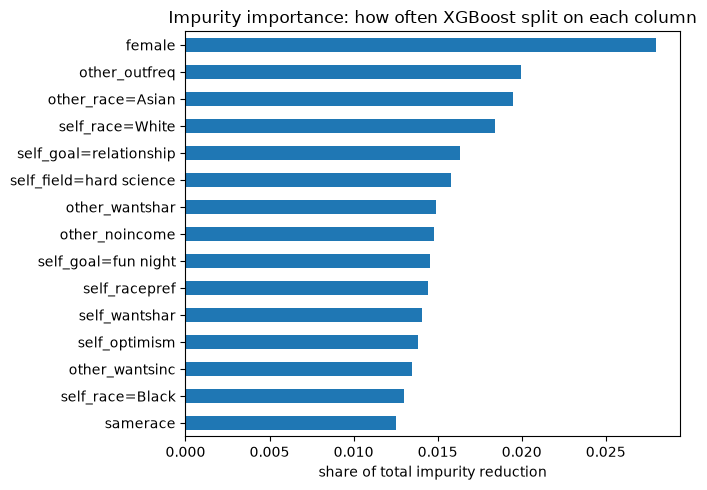

In [8]:
importance = pd.Series(final["xgboost"][-1].feature_importances_, index=COLUMNS)
importance = (importance / importance.sum()).nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
importance.plot.barh(ax=ax)
ax.set_xlabel("share of total impurity reduction")
ax.set_title("Impurity importance: how often XGBoost split on each column")
plt.tight_layout()
plt.savefig("reports/figures/04_impurity_importance.png", dpi=150)
plt.show()

**What it says.** The categorical blocks come first, which is the bias just described rather than a
finding: eighteen fields offer eighteen times more places to split.

Partial dependence next: the average prediction as one column moves. It averages over the
**marginal** distribution of the others, so the curve covers combinations that never occur.

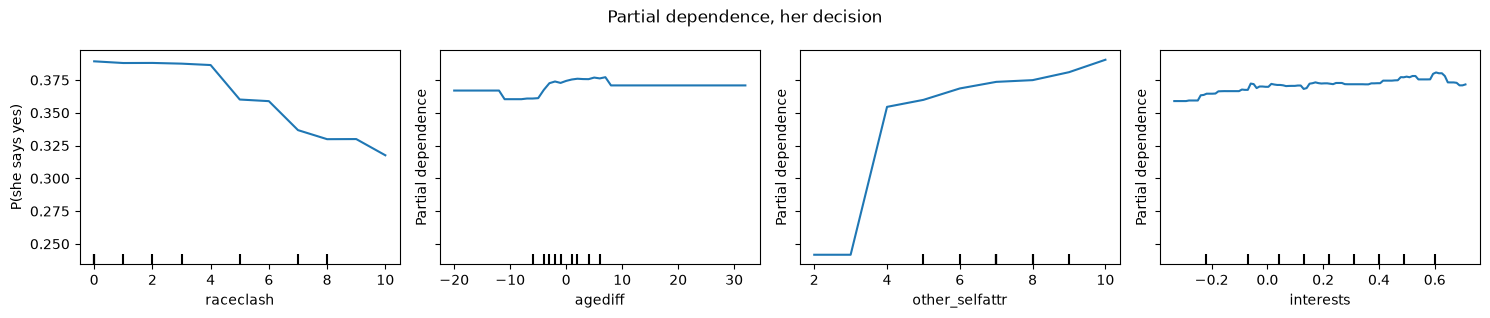

In [9]:
PDP_COLUMNS = ["raceclash", "agediff", "other_selfattr", "interests"]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=True)
PartialDependenceDisplay.from_estimator(final["xgboost"], hers, PDP_COLUMNS, ax=axes)
axes[0].set_ylabel("P(she says yes)")
fig.suptitle("Partial dependence, her decision")
plt.tight_layout()
plt.savefig("reports/figures/04_pdp.png", dpi=150)
plt.show()

**What it says.** `raceclash` falls steadily from 39% to 32%, `agediff` is flat, `interests` rises
gently. `other_selfattr` jumps between 3 and 4, but **that jump is an artefact**: only 4.8% of
participants rate their own looks 4 or below, so the model extrapolates there.

Centred ICE draws one line per pair from a common start. A fan that opens means the effect depends on
who the person is.

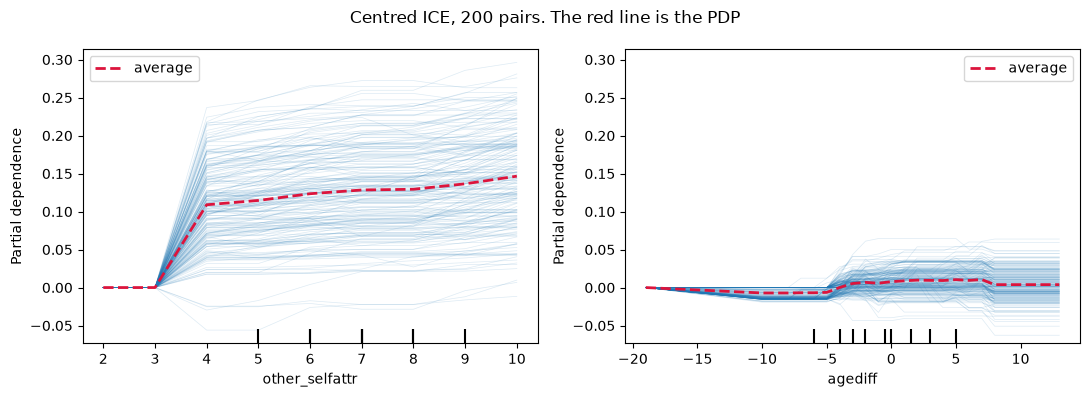

In [10]:
sample = hers.sample(200, random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
PartialDependenceDisplay.from_estimator(final["xgboost"], sample, ["other_selfattr", "agediff"],
                                        kind="both", centered=True, ax=axes,
                                        ice_lines_kw={"alpha": 0.15, "linewidth": 0.5},
                                        pd_line_kw={"color": "crimson", "linewidth": 2})
fig.suptitle("Centred ICE, 200 pairs. The red line is the PDP")
plt.tight_layout()
plt.savefig("reports/figures/04_ice.png", dpi=150)
plt.show()

**What it says.** For `other_selfattr` the fan opens wide: an average gain of 11 points hides pairs
worth 30 and pairs worth nothing. For `agediff` it stays closed, so the flat curve is real.

**Conclusion.** The age gap does nothing, although both sides state a preference over it. The
partner's self-rated looks matter enormously for some pairs and not at all for others.

## 3. Why this pair

SHAP splits one prediction into one contribution per column, exactly: `Σφ + φ₀ = margin` on the
log-odds of a single decision.

efficiency check, worst pair: |sum of contributions + base - margin| = 2.86e-06


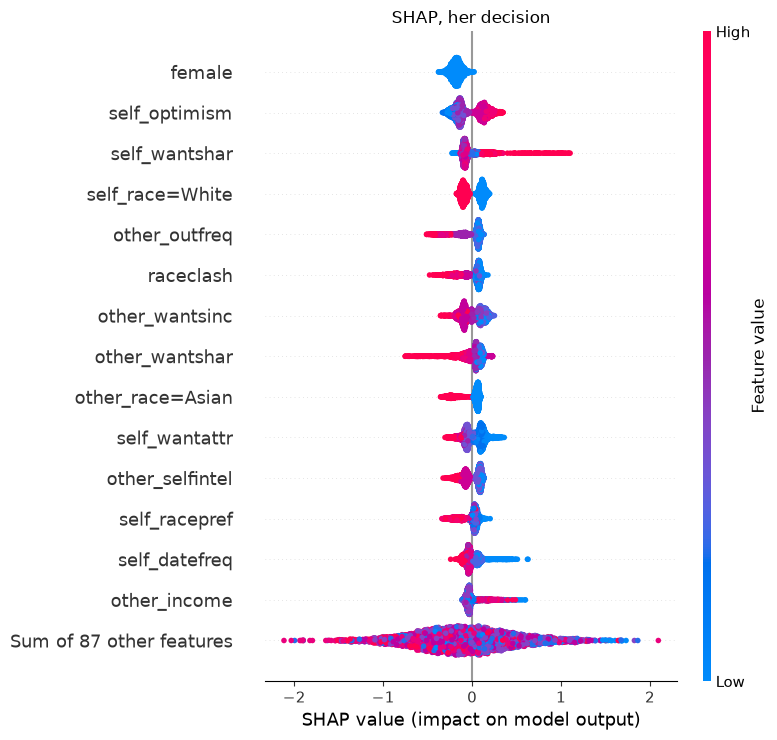

In [11]:
explainer = shap.TreeExplainer(final["xgboost"][-1])
shap_her = explainer(design(final["xgboost"], hers))
shap_his = explainer(design(final["xgboost"], his))

margin = final["xgboost"][-1].predict(design(final["xgboost"], hers).to_numpy(), output_margin=True)
residual = np.abs(shap_her.values.sum(1) + shap_her.base_values - margin).max()
print(f"efficiency check, worst pair: |sum of contributions + base - margin| = {residual:.2e}")

shap.plots.beeswarm(shap_her, max_display=15, show=False)
plt.title("SHAP, her decision")
plt.tight_layout()
plt.savefig("reports/figures/04_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

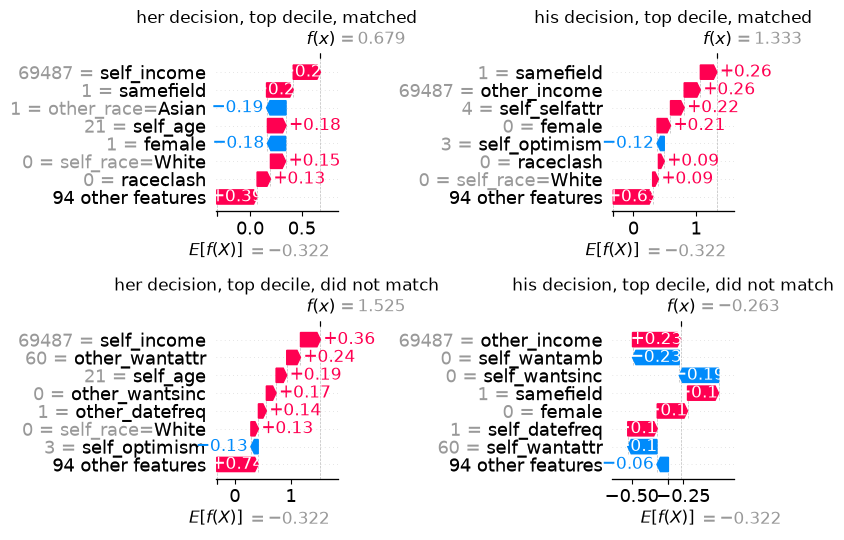

In [12]:
scores = pd.Series(out_of_fold("xgboost"), index=table.index)
shown = scores >= scores.quantile(0.9)
hit = table.index[shown & (table.match == 1)][0]
miss = table.index[shown & (table.match == 0)][0]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, (label, pair) in enumerate([("matched", hit), ("did not match", miss)]):
    for col, (stage, values) in enumerate([("her decision", shap_her), ("his decision", shap_his)]):
        plt.sca(axes[row, col])
        shap.plots.waterfall(values[pair], max_display=8, show=False)
        axes[row, col].set_title(f"{stage}, top decile, {label}")
plt.tight_layout()
plt.savefig("reports/figures/04_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

**What it says.** The efficiency check holds to three millionths. A pair reaches the shortlist by
accumulating six or seven small contributions, never one large one.

LIME answers the same question differently: it fits a small linear model around this one pair and
returns **rules** rather than exact contributions.

In [13]:
from lime.lime_tabular import LimeTabularExplainer

lime_x = design(final["xgboost"], hers)
explain_local = LimeTabularExplainer(lime_x.to_numpy(), feature_names=COLUMNS,
                                     class_names=["no", "yes"], discretize_continuous=True,
                                     random_state=SEED)
rules = explain_local.explain_instance(lime_x.loc[hit].to_numpy(),
                                       lambda m: final["xgboost"][-1].predict_proba(m),
                                       num_features=6)
pd.DataFrame(rules.as_list(), columns=["rule", "weight"]).round(3)

,rule,weight
0,self_race=Black <= 0.00,-0.068
1,other_race=Asian > 0.00,-0.057
2,self_optimism <= 4.00,-0.047
3,other_selfintel <= 8.00,0.035
4,self_race=White <= 0.00,0.034
5,other_selfamb <= 7.00,0.033


**What it says.** The rules are readable as they stand, for instance `self_optimism <= 4.00` pushing
the prediction down.

**Conclusion.** Both work, and they are complementary. SHAP allocates the prediction exactly and is
what we would log; LIME phrases it as conditions and is what we would show a user. This is the format
the client needs: every recommendation can be given its reasons.

## 4. Does each column earn its place?

SHAP explains a prediction, not whether a column is worth having. Permutation importance shuffles one
column and measures how far the **out-of-fold** score falls. Out of fold matters: shuffled in sample,
a column looks important simply for having been memorised.

In [14]:
RATES = {"PR-AUC": lambda s: average_precision_score(table.match, s),
         "top decile": lambda s: table.match[s >= np.quantile(s, 0.9)].mean()}

def permutation_importance(name, n_repeats=20, seed=SEED):
    rng = np.random.default_rng(seed)
    reference = {m: f(out_of_fold(name)) for m, f in RATES.items()}
    rows = []
    for column in hers.columns:
        drops = {m: [] for m in RATES}
        for _ in range(n_repeats):
            her_view, his_view = hers.copy(), his.copy()
            shuffled = rng.permutation(np.r_[her_view[column].to_numpy(), his_view[column].to_numpy()])
            her_view[column], his_view[column] = shuffled[:len(hers)], shuffled[len(hers):]
            score = out_of_fold(name, her_view, his_view)
            for m, f in RATES.items():
                drops[m].append(reference[m] - f(score))
        row = {"feature": column}
        for m in RATES:
            row[m] = np.mean(drops[m])
            row[f"{m} ± "] = 1.96 * np.std(drops[m]) / np.sqrt(n_repeats)
        rows.append(row)
    return pd.DataFrame(rows).set_index("feature")

permutation = permutation_importance("xgboost")
permutation.sort_values("top decile", ascending=False).head(12).round(4)

,PR-AUC,PR-AUC ±,top decile,top decile ±
feature,,,,
other_datefreq,0.0055,0.0007,0.0354,0.0030
raceclash,0.0072,0.0009,0.0320,0.0043
self_optimism,0.0036,0.0008,0.0311,0.0046
other_race,0.0075,0.0007,0.0307,0.0032
other_wantamb,0.0046,0.0005,0.0276,0.0025
female,0.0057,0.0014,0.0261,0.0045
other_wantattr,0.0027,0.0006,0.0260,0.0040
self_race,0.0036,0.0011,0.0242,0.0040
other_selffun,0.0016,0.0005,0.0226,0.0024


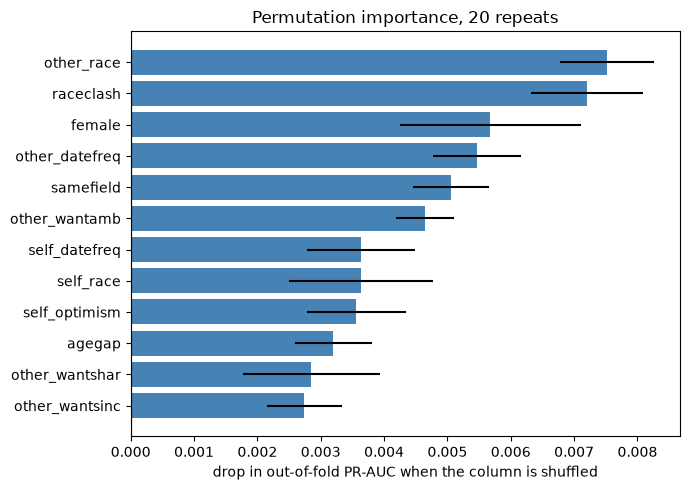

In [15]:
best = permutation.sort_values("PR-AUC", ascending=False).head(12).iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(best.index, best["PR-AUC"], xerr=best["PR-AUC ± "], color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("drop in out-of-fold PR-AUC when the column is shuffled")
ax.set_title("Permutation importance, 20 repeats")
plt.tight_layout()
plt.savefig("reports/figures/04_permutation_importance.png", dpi=150)
plt.show()
permutation.to_csv("reports/tables/04_permutation_importance.csv")

**What it says.** The drops are a few thousandths of PR-AUC and their intervals overlap. The top four
are `other_race`, `raceclash`, `self_income` and `female`.

**Conclusion.** Two of the four are built from ethnicity. Not a fairness verdict on its own, but the
reason 06 exists.

TabPFN has no coefficients and no trees, so permutation importance is the only way to open it. 03b
computed it on Colab, by feature group.

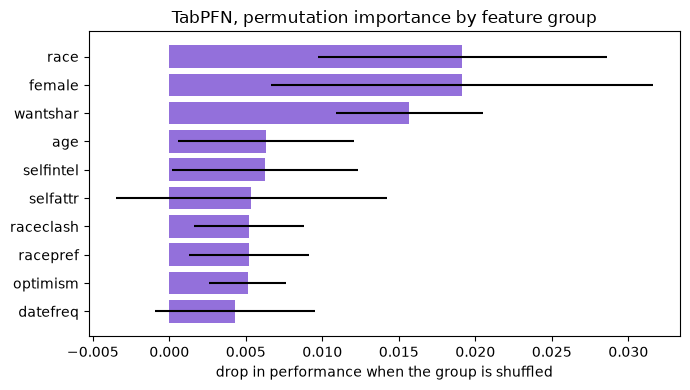

,mean,std
group,,
race,0.0192,0.0095
female,0.0191,0.0125
wantshar,0.0157,0.0048
age,0.0063,0.0057
selfintel,0.0063,0.0061
selfattr,0.0053,0.0089
raceclash,0.0052,0.0036
racepref,0.0052,0.0039
optimism,0.0051,0.0025


In [16]:
# TabPFN has no coefficients and no trees, so permutation importance is the only way in.
# 03b computed it on Colab, one drop per feature group per fold.
groups = pd.read_csv("data/processed/tabpfn_importance.csv")
ranked = groups.groupby("group")["drop"].agg(["mean", "std"]).nlargest(10, "mean").iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(ranked.index, ranked["mean"], xerr=ranked["std"], color="mediumpurple")
ax.set_xlabel("drop in performance when the group is shuffled")
ax.set_title("TabPFN, permutation importance by feature group")
plt.tight_layout()
plt.savefig("reports/figures/04_tabpfn_importance.png", dpi=150)
plt.show()
ranked.iloc[::-1].round(4)

**What it says.** `race` is the group TabPFN leans on most, then `female` and `wantshar`.

**Conclusion.** The three engines agree on where the signal is, ethnicity included. A foundation
model is not more neutral for being harder to read.

### XPER

XPER splits the performance measure itself: PM = φ₀ + Σφⱼ, φ₀ being the AUC of an uninformed model,
0.5. It enumerates coalitions, so it runs on the eight strongest columns refitted into their own
model, in approximate mode.

In [17]:
import contextlib, io

from XPER.compute.Performance import ModelPerformance

encoded = design(final["xgboost"], decisions)
ranked = permutation.sort_values("PR-AUC", ascending=False).index
top_eight = [c for c in ranked if c in encoded.columns][:8]   # the one-hot blocks cannot be split
train, test = (side_fold != 0).to_numpy(), (side_fold == 0).to_numpy()
reduced = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                        colsample_bytree=0.8, eval_metric="logloss", random_state=0)
reduced.fit(encoded.loc[train, top_eight].to_numpy(), answers[train].to_numpy())

measure = ModelPerformance(encoded.loc[train, top_eight].to_numpy(), answers[train].to_numpy(),
                           encoded.loc[test, top_eight].to_numpy(), answers[test].to_numpy(),
                           reduced, sample_size=100, seed=SEED)
performance = measure.evaluate(["AUC"])
with contextlib.redirect_stderr(io.StringIO()):          # the progress bar floods the notebook
    phi, _ = measure.calculate_XPER_values(["AUC"], kernel=True, N_coalition_sampled=2**8 - 2)

xper = pd.Series(phi[1:], index=top_eight).sort_values()
measured = float(np.ravel(performance)[0])
print(f"AUC of the reduced model: {measured:.3f}")
print(f"benchmark phi_0: {phi[0]:.3f}   phi_0 + sum(phi_j): {phi[0] + sum(phi[1:]):.3f}   "
      f"gap left by the approximation: {abs(measured - phi[0] - sum(phi[1:])):.3f}")

AUC of the reduced model: 0.571
benchmark phi_0: 0.516   phi_0 + sum(phi_j): 0.558   gap left by the approximation: 0.013


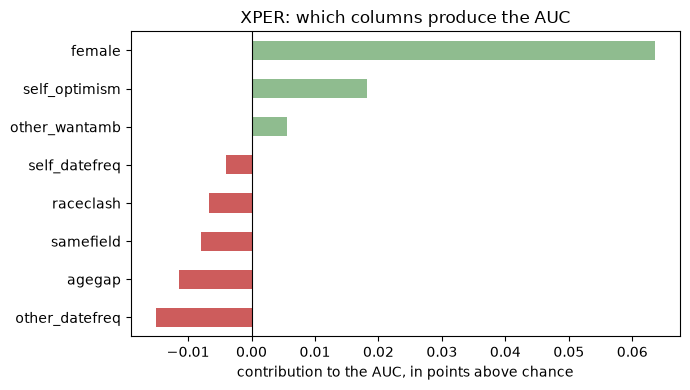

female            0.0636
self_optimism     0.0181
other_wantamb     0.0056
self_datefreq    -0.0041
raceclash        -0.0067
samefield        -0.0080
agegap           -0.0115
other_datefreq   -0.0151
dtype: float64

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
xper.plot.barh(ax=ax, color=np.where(xper > 0, "darkseagreen", "indianred"))
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("contribution to the AUC, in points above chance")
ax.set_title("XPER: which columns produce the AUC")
plt.tight_layout()
plt.savefig("reports/figures/04_xper.png", dpi=150)
plt.show()
xper.sort_values(ascending=False).round(4)

**What it says.** `female` produces most of the skill on its own, then `self_optimism`. Several
contributions are **negative**: the column costs performance rather than adding to it.

**Conclusion.** Impurity importance cannot show that. A column the tree splits on constantly can still
be subtracting from the score.

## 5. Do the methods agree?

Four measures of importance, four different questions: how often the tree split, how much a
prediction moves, how much performance is lost, how much skill is produced.

In [19]:
shap_size = pd.Series(np.abs(shap_her.values).mean(0), index=COLUMNS)

def to_features(series):
    # Collapse the one-hot columns back onto the variable they came from, so the four are comparable.
    base = pd.Series({c: c.split("=")[0] for c in series.index})
    return series.abs().groupby(base).sum()

rankings = pd.DataFrame({
    "impurity": to_features(pd.Series(final["xgboost"][-1].feature_importances_, index=COLUMNS)),
    "permutation": permutation["PR-AUC"].abs(),
    "SHAP": to_features(shap_size),
    "XPER": to_features(xper)})

top5 = {m: set(rankings[m].nlargest(5).index) for m in rankings}
comparison = pd.DataFrame({m: rankings[m].nlargest(5).index.tolist() for m in rankings},
                          index=[f"#{i+1}" for i in range(5)])
agreement = pd.DataFrame({a: {b: len(top5[a] & top5[b]) / 5 for b in top5} for a in top5})
comparison

,impurity,permutation,SHAP,XPER
#1,self_field,other_race,female,female
#2,other_field,raceclash,self_optimism,self_optimism
#3,self_goal,self_income,self_race,other_datefreq
#4,other_race,female,other_race,agegap
#5,self_race,other_datefreq,self_wantshar,samefield


In [20]:
agreement.round(2)

,impurity,permutation,SHAP,XPER
impurity,1.0,0.2,0.4,0.0
permutation,0.2,1.0,0.4,0.4
SHAP,0.4,0.4,1.0,0.4
XPER,0.0,0.4,0.4,1.0


**What it says.** They share 30% of their top five, and impurity and XPER share nothing at all.

**Conclusion.** One importance chart on a slide would be a choice presented as a fact. If one has to
be picked it is XPER, because the client asks where the skill comes from, not where the tree looked.

## 6. Would a simple tree do instead?

A depth-3 tree fitted on the **scores** of XGBoost. If it reproduced them, the black box was simple
all along. Fidelity is the R² of the tree on those scores.

fidelity (R² on the black box scores): 0.242


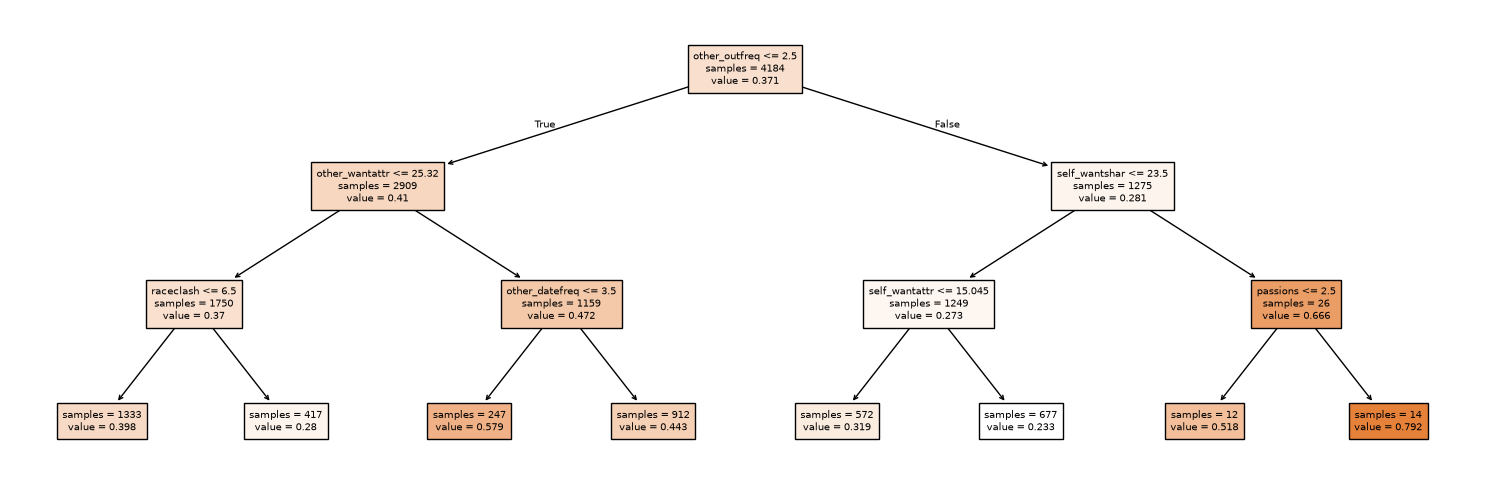

In [21]:
surrogate_x = design(final["xgboost"], hers)
surrogate_y = final["xgboost"].predict_proba(hers)[:, 1]
surrogate = DecisionTreeRegressor(max_depth=3, random_state=SEED).fit(surrogate_x, surrogate_y)
print(f"fidelity (R² on the black box scores): {r2_score(surrogate_y, surrogate.predict(surrogate_x)):.3f}")

fig, ax = plt.subplots(figsize=(15, 5))
plot_tree(surrogate, feature_names=COLUMNS, filled=True, fontsize=7, ax=ax, impurity=False)
plt.tight_layout()
plt.savefig("reports/figures/04_surrogate_tree.png", dpi=150)
plt.show()

**What it says.** Fidelity 0.24.

**Conclusion.** A three-question tree recovers a quarter of the model and would misrepresent it. The
simplicity of a small tree would be an illusion here.

## 7. What the engine is worth

The baseline the client has on day one is showing pairs at random, 165 matches per 1,000.

In [22]:
base = oof.match.mean()
rows = []
for k in [0.05, 0.10, 0.20]:
    for name in ["logit", "xgboost", "logit_direct", "xgboost_direct"]:
        point, low, high = bootstrap_ci(oof, lambda d, n=name, q=k: top_k_rate(d, n, q), n_boot=500)
        shown = int(k * len(oof))
        rows.append({"shown": f"top {k:.0%}", "model": name, "match rate": round(point, 3),
                     "95% CI": f"[{low:.3f}, {high:.3f}]", "lift over random": round(point / base, 2),
                     "matches per 1,000 shown": int(round(1000 * point)),
                     "extra matches per 1,000": int(round(1000 * (point - base))),
                     "extra matches over the catalogue": int(round(shown * (point - base)))})

economics = pd.DataFrame(rows).set_index(["shown", "model"])
economics.to_csv("reports/tables/04_economic_performance.csv")
economics.loc[(slice(None), "logit"), :]

,,match rate,95% CI,lift over random,"matches per 1,000 shown","extra matches per 1,000",extra matches over the catalogue
shown,model,,,,,,
top 5%,logit,0.319,"[0.252, 0.376]",1.93,319,154,32
top 10%,logit,0.298,"[0.249, 0.337]",1.81,298,133,56
top 20%,logit,0.235,"[0.205, 0.265]",1.43,235,70,59


In [23]:
economics.loc[(slice(None), "logit"), ["extra matches per 1,000", "extra matches over the catalogue"]]

,,"extra matches per 1,000",extra matches over the catalogue
shown,model,,
top 5%,logit,154,32
top 10%,logit,133,56
top 20%,logit,70,59


**What it says.** 298 matches per 1,000 in the top decile, still 235 at the top 20%.

**Where the ×1.81 comes from.** 690 of 4,184 pairs matched, so random gives 16.5%. The top decile is
419 pairs of which 125 matched, 29.8%, and 0.298 / 0.165 = 1.81. Out-of-fold and grouped by wave, so
it is what a **new** user gets; interval [1.55, 2.04].

In [24]:
def lift(frame, column="logit", k=0.10):
    shown = frame[frame[column] >= frame[column].quantile(1 - k)]
    return shown.match.mean() / frame.match.mean()

for k in [0.05, 0.10, 0.20]:
    point, low, high = bootstrap_ci(oof, lambda d, q=k: lift(d, k=q), n_boot=2000)
    shown = oof[oof.logit >= oof.logit.quantile(1 - k)]
    print(f"top {k:4.0%}: {len(shown):4d} pairs shown, {int(shown.match.sum()):3d} matched "
          f"({shown.match.mean():.3f}) against a {oof.match.mean():.3f} base rate"
          f"  ->  x{point:.2f}, 95% CI [{low:.2f}, {high:.2f}]")

top   5%:  210 pairs shown,  67 matched (0.319) against a 0.165 base rate  ->  x1.93, 95% CI [1.57, 2.31]


top  10%:  419 pairs shown, 125 matched (0.298) against a 0.165 base rate  ->  x1.81, 95% CI [1.56, 2.04]


top  20%:  837 pairs shown, 197 matched (0.235) against a 0.165 base rate  ->  x1.43, 95% CI [1.28, 1.58]


**Conclusion on the shortlist.** A short list is more efficient per slot, 149 extra matches per 1,000
at the top 5% against 70 at the top 20%; a long list delivers more in total, 31 extra pairs against
59. The length of the list is the client's decision.

**Value per 1,000 recommendations = 133 × v**, v the net value of one extra match. What it costs to
produce is measured below.

In [25]:
import time

candidates = pd.concat([decisions] * 24, ignore_index=True)     # about 200,000 candidate pairs
start = time.perf_counter()
final["logit"].predict_proba(candidates)
per_pair = (time.perf_counter() - start) / len(candidates)

SCORES_PER_USER_MONTH = 30_000          # 1,000 candidates, refreshed once a day
VCPU_PER_HOUR = 0.15                    # a managed cloud core
monthly_cost = SCORES_PER_USER_MONTH * per_pair / 3600 * VCPU_PER_HOUR

print(f"scoring one pair:            {1e6 * per_pair:.1f} microseconds")
print(f"a full retrain:              under a second on 8,368 decisions")
print(f"per subscriber per month:    {SCORES_PER_USER_MONTH * per_pair * 1000:.0f} ms of CPU, "
      f"${monthly_cost:.8f}")
print(f"per 1,000 users per year:    ${1000 * 12 * monthly_cost:.3f}")

scoring one pair:            2.3 microseconds
a full retrain:              under a second on 8,368 decisions
per subscriber per month:    69 ms of CPU, $0.00000289
per 1,000 users per year:    $0.035


A few cents per 1,000 users per year, so the engine cannot be priced on what it costs. Two numbers
come from the client instead: **`c`**, the share who pay, market band 8% to 15%, and **`r`**, the
extra paid months a satisfied subscriber stays.

In [26]:
CONVERSION = 0.12          # share of users on a paid plan; scale the table linearly for another value

value = pd.DataFrame(
    {f"+{months} month" + ("s" if months != 1 else ""):
     {f"${price}/month": int(1000 * CONVERSION * price * months)
      for price in [10, 15, 20, 30]}
     for months in [0.25, 0.5, 1, 2]})
value.index.name = "subscription price"
value.to_csv("reports/tables/04_unit_economics.csv")
print(f"annual value per 1,000 users, at {CONVERSION:.0%} conversion (dollars)")
value

annual value per 1,000 users, at 12% conversion (dollars)


,+0.25 months,+0.5 months,+1 month,+2 months
subscription price,,,,
$10/month,300,600,1200,2400
$15/month,450,900,1800,3600
$20/month,600,1200,2400,4800
$30/month,900,1800,3600,7200


**Conclusion.** At $15 a month, 12% conversion and one extra paid month, the engine is worth **$1,800
per 1,000 users per year**, tens of thousands of times what it costs to run. Shipping it is never a
cost decision. 06 prices the other side: removing the amplification costs 50 matches per 1,000.

## What goes on the slide

In [27]:
print(f"white box keeps {len(kept)} of {len(COLUMNS)} columns")
print(f"strongest marginal effect: {coefficients.index[0]} at "
      f"{coefficients['Marginal Effect (%)'].iloc[0]:+.1f} points")
print(f"strongest continuous effect: {continuous.index[0]} at "
      f"{continuous['Marginal Effect (%)'].iloc[0]:+.1f} points per standard deviation")
print(f"top-decile match rate {top_k_rate(oof, 'logit'):.3f} against {base:.3f} at random "
      f"-> {top_k_rate(oof, 'logit') / base:.2f}x")
print(f"the four importance methods share {agreement.to_numpy()[np.triu_indices(4, 1)].mean():.0%} "
      f"of their top five")
print(f"surrogate tree fidelity {r2_score(surrogate_y, surrogate.predict(surrogate_x)):.2f}")
print(f"cost of running the engine: ${1000 * 12 * monthly_cost:.3f} per 1,000 users per year")
print(f"value at $15/month, 12% conversion, one extra paid month: "
      f"${value.loc['$15/month', '+1 month']:,} per 1,000 users per year")

white box keeps 77 of 101 columns
strongest marginal effect: female at -13.7 points
strongest continuous effect: other_selfintel at -4.0 points per standard deviation
top-decile match rate 0.298 against 0.165 at random -> 1.81x
the four importance methods share 30% of their top five
surrogate tree fidelity 0.24
cost of running the engine: $0.035 per 1,000 users per year
value at $15/month, 12% conversion, one extra paid month: $1,800 per 1,000 users per year
